In [203]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Análisis exploratorio

In [204]:
df = pd.read_csv("adult.csv", na_values=["?"], skipinitialspace=True)

In [205]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [206]:
print(df.size)
print(df.shape)

732630
(48842, 15)


In [207]:
df.isna().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

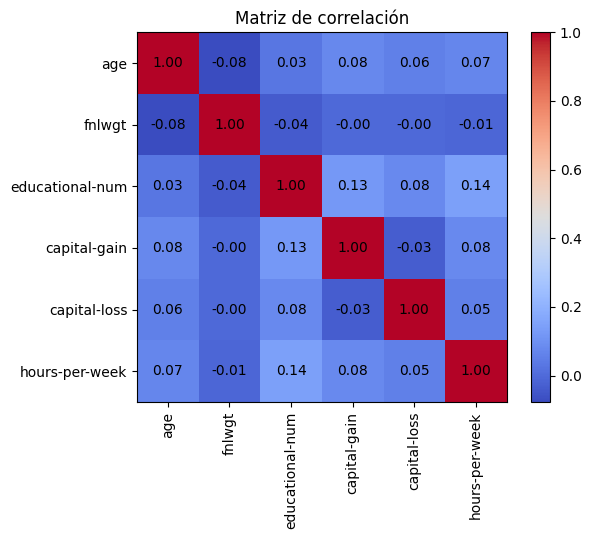

In [208]:
corr = df.corr(numeric_only=True)
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")
plt.title("Matriz de correlación")
plt.show()

# Preprocesamiento antes de data splitting

In [209]:
# Eliminar variables duplicadas y no relevantes
df = df.drop(columns=["educational-num", "fnlwgt"])

In [210]:
# Reemplazar valores faltantes por "Unknown"
df["workclass"] = df["workclass"].fillna("Unknown")
df["occupation"] = df["occupation"].fillna("Unknown")
df["native-country"] = df["native-country"].fillna("Unknown")

In [211]:
# separarar features y target
X = df.drop("income", axis=1)
y = df["income"]

# quitar "." de valores como "<=50K." y ">50K."
y = y.str.replace(".", "", regex=False)
# convertir strings a 0 y 1 (binario)
y = y.map({"<=50K": 0, ">50K": 1})

In [212]:
y.value_counts()

income
0    37155
1    11687
Name: count, dtype: int64

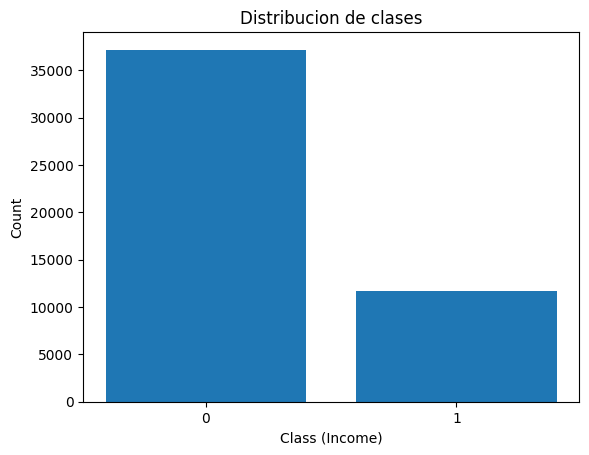

In [213]:
counts = y.value_counts()
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Class (Income)")
plt.ylabel("Count")
plt.title("Distribucion de clases")
plt.show()

In [214]:
X

,age,workclass,education,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,Unknown,Some-college,Never-married,Unknown,Own-child,White,Female,0,0,30,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
48838,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
48839,58,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
48840,22,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States


# Data splitting

In [215]:
from sklearn.model_selection import train_test_split
# Separar en dataset de training y dataset de testing
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Preprocesamiento después de data splitting

In [216]:
# Identificar variables numéricas y categóricas
categorical_cols = X_train_full.select_dtypes(include=["object", "string", "category"]).columns
numerical_cols = X_train_full.select_dtypes(exclude=["object", "string", "category"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']
Numerical columns: ['age', 'capital-gain', 'capital-loss', 'hours-per-week']


In [217]:
# Escalado necesario para variables numéricas y one-hot encoding para variables categóricas
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

In [218]:
X_train = preprocessor.fit_transform(X_train_full)
X_test = preprocessor.transform(X_test)

# Implementaciòn del modelo

In [219]:
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [220]:
input_dim = X_train.shape[1]
model = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])


In [221]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [222]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │         6,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,961 (35.00 KB)

 Trainable params: 8,961 (35.00 KB)

 Non-trainable params: 0 (0.00 B)

In [223]:
history = model.fit(
    X_train,
    y_train_full,
    validation_split=0.2,
    epochs=18,
    batch_size=32,
    verbose=2
)


Epoch 1/18
977/977 - 4s - 4ms/step - accuracy: 0.8447 - loss: 0.3322 - precision: 0.7238 - recall: 0.5703 - val_accuracy: 0.8553 - val_loss: 0.3154 - val_precision: 0.7323 - val_recall: 0.6132
Epoch 2/18
977/977 - 2s - 2ms/step - accuracy: 0.8568 - loss: 0.3073 - precision: 0.7369 - recall: 0.6270 - val_accuracy: 0.8545 - val_loss: 0.3137 - val_precision: 0.7500 - val_recall: 0.5786
Epoch 3/18
977/977 - 2s - 2ms/step - accuracy: 0.8586 - loss: 0.3025 - precision: 0.7419 - recall: 0.6296 - val_accuracy: 0.8530 - val_loss: 0.3148 - val_precision: 0.7188 - val_recall: 0.6229
Epoch 4/18
977/977 - 2s - 2ms/step - accuracy: 0.8599 - loss: 0.3007 - precision: 0.7461 - recall: 0.6304 - val_accuracy: 0.8541 - val_loss: 0.3156 - val_precision: 0.7080 - val_recall: 0.6537
Epoch 5/18
977/977 - 2s - 2ms/step - accuracy: 0.8621 - loss: 0.2975 - precision: 0.7509 - recall: 0.6358 - val_accuracy: 0.8528 - val_loss: 0.3153 - val_precision: 0.7370 - val_recall: 0.5889
Epoch 6/18
977/977 - 2s - 2ms/step 

# Evaluación inicial del modelo

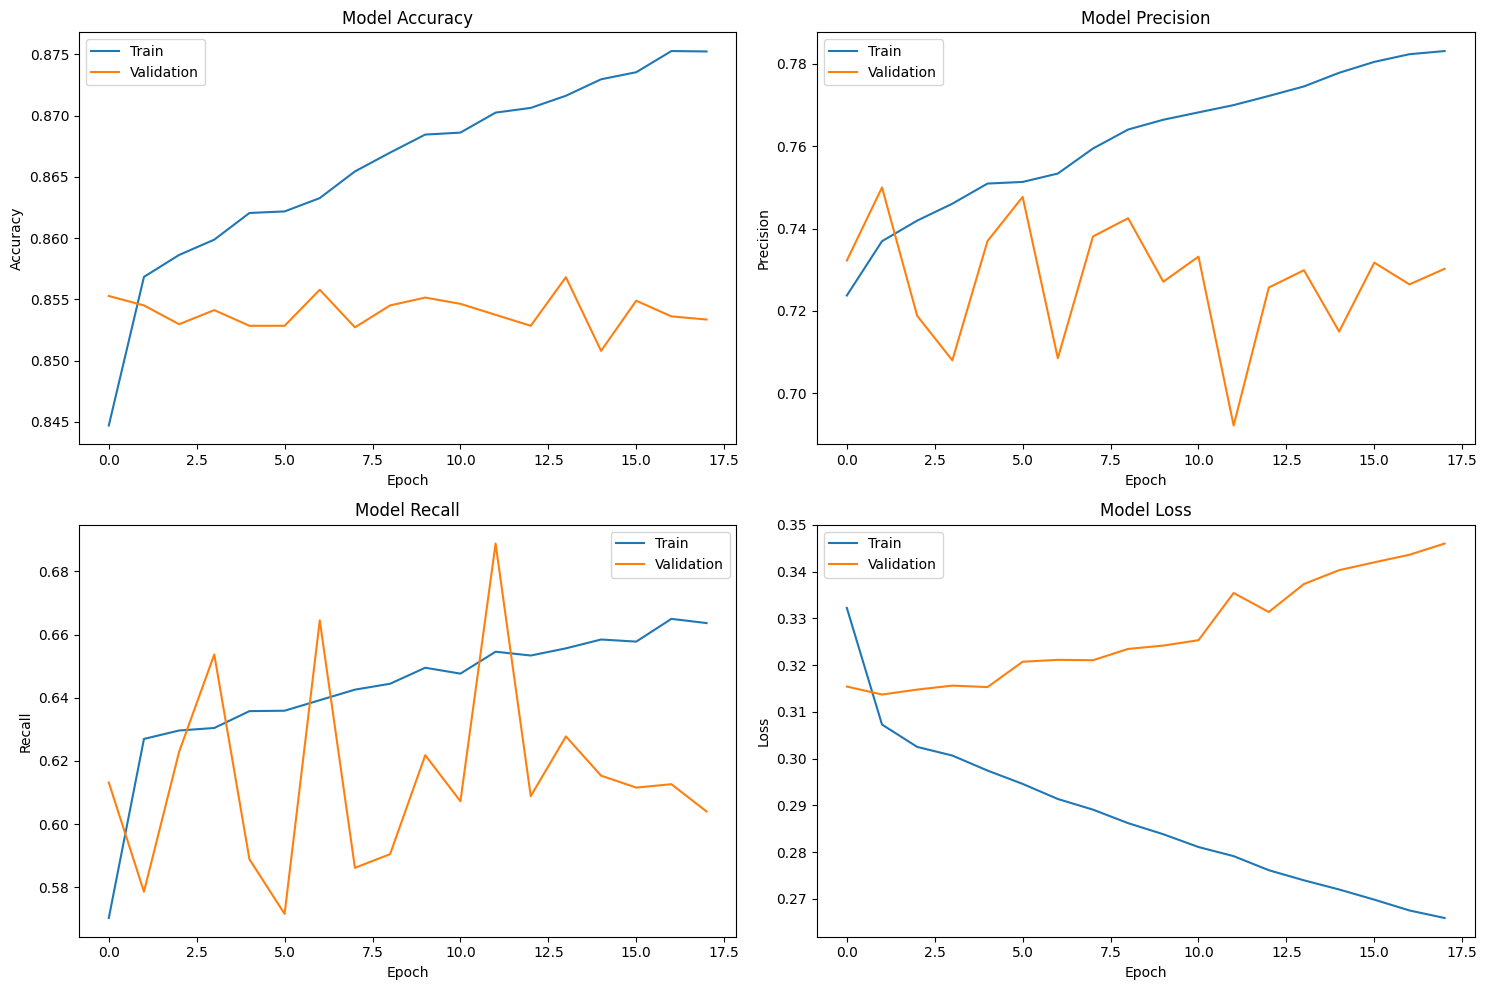

In [227]:
history_dict = history.history
epochs = range(len(history_dict['loss']))

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.plot(epochs, history_dict['accuracy'], label='Train')
plt.plot(epochs, history_dict['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(2,2,2)
plt.plot(epochs, history_dict['precision'], label='Train')
plt.plot(epochs, history_dict['val_precision'], label='Validation')
plt.title('Model Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()

plt.subplot(2,2,3)
plt.plot(epochs, history_dict['recall'], label='Train')
plt.plot(epochs, history_dict['val_recall'], label='Validation')
plt.title('Model Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()

plt.subplot(2,2,4)
plt.plot(epochs, history_dict['loss'], label='Train')
plt.plot(epochs, history_dict['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [232]:
loss, accuracy, precision, recall = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", loss)

Test loss: 0.3308316767215729


In [237]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step


In [238]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))


Accuracy: 0.8558706111167981
Precision: 0.7394438722966015
Recall: 0.6142001710863987
F1-score: 0.6710280373831776


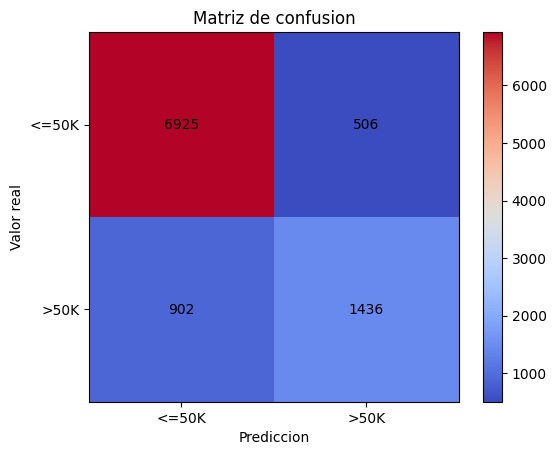

In [239]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()

plt.imshow(cm, cmap="coolwarm")
plt.title("Matriz de confusion")
plt.xlabel("Prediccion")
plt.ylabel("Valor real")

plt.xticks([0,1], ["<=50K", ">50K"])
plt.yticks([0,1], ["<=50K", ">50K"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center")

plt.colorbar()
plt.show()